# Detecția atacurilor brute-force din loguri Windows (Event ID 4625)

Notebook de analiză pentru proiectul din acest repository. **Toate datele sunt sintetice** (generate de cod), nu există loguri reale. Ideea: comparăm o *regulă simplă* (ce ar scrie un analist SOC într-un SIEM) cu un model de învățare automată nesupervizat (*Isolation Forest*).

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from detectie_bruteforce.generate_data import Config, generate_events
from detectie_bruteforce.features import build_features, FEATURE_COLUMNS
from detectie_bruteforce.models import rule_baseline, isolation_forest, evaluate

pd.set_option('display.width', 140)

## 1. Datele sintetice

Fiecare rând este un eveniment de autentificare: `4624` = login reușit, `4625` = login eșuat. Coloana `attack_type` spune ce este evenimentul în realitate (`none`, `brute_force`, `password_spray`); o folosim **doar pentru evaluare**, modelul nu o vede.

In [2]:
events = generate_events(Config(seed=42))
print(len(events), 'evenimente')
events.head()

27039 evenimente


,timestamp,event_id,user,src_ip,host,attack_type
0,2026-01-05 00:04:34,4624,user033,10.0.0.34,HOST-07,none
1,2026-01-05 00:10:46,4624,user045,10.0.0.46,HOST-03,none
2,2026-01-05 00:18:29,4624,user014,10.0.0.15,HOST-03,none
3,2026-01-05 00:19:04,4624,user036,10.0.0.37,HOST-10,none
4,2026-01-05 00:21:40,4624,user077,10.0.0.78,HOST-04,none


In [3]:
events.groupby(['attack_type', 'event_id']).size().unstack(fill_value=0)

event_id,4624,4625
attack_type,,
brute_force,1,554
none,25447,880
password_spray,0,157


## 2. Ferestre de 5 minute per adresă IP

Un analist nu judecă un eveniment izolat, ci ce face o adresă într-un interval scurt. Construim câte o linie pentru fiecare pereche (IP, fereastră de 5 minute) și calculăm caracteristici (număr de eșecuri, câți utilizatori diferiți au eșuat, câte calculatoare au fost țintite etc.).

In [4]:
feat = build_features(events)
print(len(feat), 'ferestre;', int(feat['is_attack'].sum()), 'conțin un atac')
feat.head()

21821 ferestre; 19 conțin un atac


,src_ip,window,n_events,n_failed,n_success,n_hosts,is_attack,attack_type,n_users_failed,max_failed_per_user,success_after_failed,failed_ratio,events_per_minute
0,10.0.0.1,2026-01-05 07:20:00,1,0,1,1,False,none,0,0,0,0.0,0.2
1,10.0.0.1,2026-01-05 07:50:00,1,0,1,1,False,none,0,0,0,0.0,0.2
2,10.0.0.1,2026-01-05 07:55:00,1,0,1,1,False,none,0,0,0,0.0,0.2
3,10.0.0.1,2026-01-05 08:00:00,2,0,2,2,False,none,0,0,0,0.0,0.4
4,10.0.0.1,2026-01-05 08:20:00,2,1,1,1,False,none,1,1,1,0.5,0.4


In [5]:
# cum diferă ferestrele de atac de cele normale? (mediana fiecărei caracteristici)
feat.groupby('attack_type')[FEATURE_COLUMNS].median().round(2)

,n_events,n_failed,n_success,failed_ratio,n_users_failed,max_failed_per_user,n_hosts,success_after_failed,events_per_minute
attack_type,,,,,,,,,
brute_force,52.0,51.5,0.0,1.0,1.0,51.5,1.0,0.0,10.4
none,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.2
password_spray,15.0,15.0,0.0,1.0,12.0,2.0,7.0,0.0,3.0


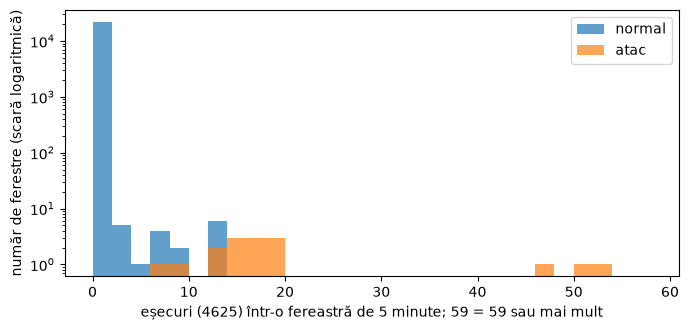

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.4))
bins = np.arange(0, 60, 2)
ax.hist(feat.loc[~feat['is_attack'], 'n_failed'].clip(upper=59), bins=bins, alpha=.7, label='normal', log=True)
ax.hist(feat.loc[feat['is_attack'], 'n_failed'].clip(upper=59), bins=bins, alpha=.7, label='atac', log=True)
ax.set_xlabel('eșecuri (4625) într-o fereastră de 5 minute; 59 = 59 sau mai mult')
ax.set_ylabel('număr de ferestre (scară logaritmică)')
ax.legend(); plt.tight_layout(); plt.show()

## 3. Cele două metode

* **Regula:** alertă dacă o adresă are cel puțin 10 eșecuri într-o fereastră de 5 minute.
* **Isolation Forest:** model nesupervizat; semnalează ferestrele cele mai „neobișnuite” și nu vede etichetele.

Isolation Forest are nevoie să știm câte ferestre semnalăm (`contamination`). Comparăm două variante: 0,5% din ferestre, și *același număr de alerte ca regula* (un analist are timp pentru un număr limitat de alerte).

In [7]:
rule = rule_baseline(feat, min_failed=10)
iff_05, _ = isolation_forest(feat, contamination=0.005, seed=42)
iff_eq, _ = isolation_forest(feat, contamination=rule.sum() / len(feat), seed=42)

rows = {}
for name, a in [('Regula (>=10 eșecuri)', rule), ('Isolation Forest, 0,5% ferestre', iff_05),
                ('Isolation Forest, același nr. de alerte', iff_eq)]:
    m = evaluate(feat, a)
    rows[name] = {'alerte': m['alerte_totale'], 'atacuri prinse (TP)': m['tp'], 'alerte false (FP)': m['fp'],
                  'atacuri ratate (FN)': m['fn'], 'precizie': round(m['precizie'], 2),
                  'recall': round(m['recall'], 2), 'F1': round(m['f1'], 2)}
tab = pd.DataFrame(rows).T
cols = ['alerte', 'atacuri prinse (TP)', 'alerte false (FP)', 'atacuri ratate (FN)']
tab[cols] = tab[cols].astype(int)
tab

,alerte,atacuri prinse (TP),alerte false (FP),atacuri ratate (FN),precizie,recall,F1
Regula (>=10 eșecuri),23,17,6,2,0.74,0.89,0.81
"Isolation Forest, 0,5% ferestre",78,19,59,0,0.24,1.00,0.39
"Isolation Forest, același nr. de alerte",11,9,2,10,0.82,0.47,0.60


In [8]:
# ce tipuri de atac prinde fiecare metodă?
out = {}
for name, a in [('Regula', rule), ('IF 0,5%', iff_05), ('IF același buget', iff_eq)]:
    t = evaluate(feat, a)['pe_tip_de_atac']
    out[name] = {k: f"{v['prinse']} / {v['ferestre_atac']}" for k, v in t.items()}
pd.DataFrame(out)

,Regula,"IF 0,5%",IF același buget
brute_force,8 / 8,8 / 8,0 / 8
password_spray,9 / 11,11 / 11,9 / 11


## 4. Ce arată și ce NU arată

* Rezultatele sunt pe **date sintetice**, construite de noi; un set real ar avea zgomot și atacuri diferite.
* O singură regulă simplă poate fi greu de învins când atacul are o „semnătură” clară (multe eșecuri repede).
* Isolation Forest poate prinde tipare pe care regula nu le vede (ex. multe conturi încercate de la o adresă), dar plătește cu multe alerte false dacă îl lăsăm să semnaleze multe ferestre.
* Rulați `python -m detectie_bruteforce.run_experiment --n-seeds 5` pentru medii pe mai multe seturi de date; un singur set de date poate induce în eroare.
* Proiectul nu este pregătit pentru producție și nu înlocuiește un SIEM.